# LSTM multivariado en Keras para los 3 productos benchmark

Este notebook adapta el flujo del articulo de GeeksforGeeks, **Multivariate Time Series Forecasting with LSTMs in Keras**: importar librerias, cargar datos, escalar, crear ventanas, entrenar una LSTM, invertir la escala, graficar y evaluar.

Referencia usada: https://www.geeksforgeeks.org/deep-learning/multivariate-time-series-forecasting-with-lstms-in-keras/

Aqui se aplica sobre los 3 productos oficiales del benchmark M5 del proyecto:

- `FOODS_3_228_CA_1_validation`: demanda alta / estable
- `FOODS_2_044_CA_3_validation`: demanda intermitente
- `HOBBIES_1_133_CA_4_validation`: bajo volumen


## 1. Librerias y configuracion

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loaders.load_m5 import load_m5_single_series
from src.experiments.common_protocol import OFFICIAL_BENCHMARK_PROTOCOL

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)

print(f"TensorFlow: {tf.__version__}")
print(f"Repo root: {ROOT}")

TensorFlow: 2.21.0
Repo root: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main


## 2. Productos del benchmark

In [2]:
BENCHMARK_PRODUCTS = [
    ("FOODS_3_228_CA_1_validation", "high_demand_stable"),
    ("FOODS_2_044_CA_3_validation", "intermittent"),
    ("HOBBIES_1_133_CA_4_validation", "low_volume"),
]

PROTOCOL = OFFICIAL_BENCHMARK_PROTOCOL
MAX_DAYS = PROTOCOL.max_days
WINDOW = PROTOCOL.context_length
TEST_DAYS = PROTOCOL.test_days
VAL_DAYS = PROTOCOL.val_days

BENCHMARK_PRODUCTS, PROTOCOL

([('FOODS_3_228_CA_1_validation', 'high_demand_stable'),
  ('FOODS_2_044_CA_3_validation', 'intermittent'),
  ('HOBBIES_1_133_CA_4_validation', 'low_volume')],
 BenchmarkProtocol(dataset_name='M5_GNN_SUBSET', num_products=16, state_id='CA', seed=42, max_days=365, min_nonzero_days=28, context_length=28, val_days=28, test_days=28, scaling_rule='fit scaler only on train segment', preprocessing_rule='raw daily sales, chronological order, NaN to 0 when needed'))

## 3. Carga de datos M5

Cada serie se carga desde `data/raw/m5`, se ordena por fecha y se recorta a los ultimos 365 dias para respetar el protocolo comun del proyecto.

In [3]:
def load_product_series(series_id: str) -> pd.DataFrame:
    df = load_m5_single_series(
        base_path=str(ROOT / "data" / "raw" / "m5"),
        random_pick=False,
        series_id=series_id,
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.iloc[-MAX_DAYS:].copy().reset_index(drop=True)
    df["price"] = df["price"].ffill().bfill().fillna(0.0)
    return df


series_preview = []
series_data = {}

for series_id, label in BENCHMARK_PRODUCTS:
    df = load_product_series(series_id)
    series_data[series_id] = df
    series_preview.append(
        {
            "series_id": series_id,
            "label": label,
            "start": df["date"].min().date(),
            "end": df["date"].max().date(),
            "days": len(df),
            "mean_sales": df["sales"].mean(),
            "zero_rate": (df["sales"] == 0).mean(),
        }
    )

pd.DataFrame(series_preview)

,series_id,label,start,end,days,mean_sales,zero_rate
0,FOODS_3_228_CA_1_validation,high_demand_stable,2015-04-26,2016-04-24,365,7.008219,0.010959
1,FOODS_2_044_CA_3_validation,intermittent,2015-04-26,2016-04-24,365,0.731507,0.608219
2,HOBBIES_1_133_CA_4_validation,low_volume,2015-04-26,2016-04-24,365,0.054795,0.947945


## 4. Variables multivariadas

La LSTM recibe una ventana historica con varias variables: ventas, precio, calendario y rezagos. El objetivo sigue siendo pronosticar la venta del siguiente dia.

In [4]:
def add_time_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy().sort_values("date").reset_index(drop=True)
    out["dow"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["is_weekend"] = (out["dow"] >= 5).astype(int)

    shifted_sales = out["sales"].shift(1)
    out["lag_1"] = out["sales"].shift(1)
    out["lag_7"] = out["sales"].shift(7)
    out["lag_14"] = out["sales"].shift(14)
    out["lag_28"] = out["sales"].shift(28)
    out["ma_7"] = shifted_sales.rolling(7, min_periods=1).mean()
    out["ma_14"] = shifted_sales.rolling(14, min_periods=1).mean()
    out["ma_30"] = shifted_sales.rolling(30, min_periods=1).mean()
    out["std_7"] = shifted_sales.rolling(7, min_periods=1).std()

    feature_cols = [
        "sales",
        "price",
        "dow",
        "month",
        "is_weekend",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_28",
        "ma_7",
        "ma_14",
        "ma_30",
        "std_7",
    ]

    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out, feature_cols


example_features, feature_cols = add_time_features(series_data[BENCHMARK_PRODUCTS[0][0]])
example_features.head(), feature_cols

(        date  sales  price  dow  month  is_weekend  lag_1  lag_7  lag_14  \
 0 2015-04-26   13.0   1.68    6      4           1    0.0    0.0     0.0   
 1 2015-04-27    6.0   1.68    0      4           0   13.0    0.0     0.0   
 2 2015-04-28   11.0   1.68    1      4           0    6.0    0.0     0.0   
 3 2015-04-29    9.0   1.68    2      4           0   11.0    0.0     0.0   
 4 2015-04-30    5.0   1.68    3      4           0    9.0    0.0     0.0   
 
    lag_28   ma_7  ma_14  ma_30     std_7  
 0     0.0   0.00   0.00   0.00  0.000000  
 1     0.0  13.00  13.00  13.00  0.000000  
 2     0.0   9.50   9.50   9.50  4.949747  
 3     0.0  10.00  10.00  10.00  3.605551  
 4     0.0   9.75   9.75   9.75  2.986079  ,
 ['sales',
  'price',
  'dow',
  'month',
  'is_weekend',
  'lag_1',
  'lag_7',
  'lag_14',
  'lag_28',
  'ma_7',
  'ma_14',
  'ma_30',
  'std_7'])

## 5. Ventanas para LSTM

Como en la referencia, transformamos la serie en ventanas deslizantes: `X` contiene los ultimos `WINDOW` dias y `y` contiene las ventas del dia siguiente.

In [5]:
def create_sequences(data: np.ndarray, target_col: int, window: int) -> tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window, target_col])
    return np.asarray(X), np.asarray(y)


def inverse_target(values: np.ndarray, scaler: MinMaxScaler, n_features: int, target_col: int = 0) -> np.ndarray:
    values = np.asarray(values).reshape(-1)
    padded = np.zeros((len(values), n_features))
    padded[:, target_col] = values
    return scaler.inverse_transform(padded)[:, target_col]


def chronological_sequence_split(X: np.ndarray, y: np.ndarray, test_days: int, val_days: int):
    test_size = int(test_days)
    val_size = int(val_days)
    train_end = len(X) - test_size - val_size
    val_end = len(X) - test_size
    if train_end <= 0:
        raise ValueError("No hay suficientes ventanas para el split cronologico.")
    return (
        X[:train_end],
        y[:train_end],
        X[train_end:val_end],
        y[train_end:val_end],
        X[val_end:],
        y[val_end:],
    )

## 6. Modelo LSTM en Keras

In [6]:
def build_lstm_model(input_shape: tuple[int, int]) -> keras.Model:
    model = keras.Sequential(
        [
            keras.layers.Input(shape=input_shape),
            keras.layers.LSTM(100),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(1),
        ]
    )
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model


build_lstm_model((WINDOW, len(feature_cols))).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,701 (178.52 KB)

 Trainable params: 45,701 (178.52 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento y evaluacion para cada producto

El escalador se ajusta solo con el segmento de entrenamiento para evitar fuga de informacion del futuro.

In [7]:
EPOCHS = 30
BATCH_SIZE = 16

results = []
predictions = {}
histories = {}

for series_id, label in BENCHMARK_PRODUCTS:
    print(f"\n=== {series_id} ({label}) ===")
    raw_df = series_data[series_id]
    feat_df, feature_cols = add_time_features(raw_df)
    values = feat_df[feature_cols].to_numpy(dtype=float)

    train_rows = len(values) - TEST_DAYS - VAL_DAYS
    scaler = MinMaxScaler()
    scaler.fit(values[:train_rows])
    scaled_values = scaler.transform(values)

    X, y = create_sequences(scaled_values, target_col=0, window=WINDOW)
    X_train, y_train, X_val, y_val, X_test, y_test = chronological_sequence_split(
        X, y, test_days=TEST_DAYS, val_days=VAL_DAYS
    )

    model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0,
    )

    pred_scaled = model.predict(X_test, verbose=0).reshape(-1)
    y_test_inv = inverse_target(y_test, scaler, n_features=len(feature_cols), target_col=0)
    pred_inv = inverse_target(pred_scaled, scaler, n_features=len(feature_cols), target_col=0)
    pred_inv = np.clip(pred_inv, 0, None)

    test_dates = feat_df["date"].iloc[-len(y_test_inv):].to_numpy()
    predictions[series_id] = pd.DataFrame(
        {
            "date": test_dates,
            "actual": y_test_inv,
            "predicted": pred_inv,
        }
    )
    histories[series_id] = history.history

    mse = mean_squared_error(y_test_inv, pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, pred_inv)
    r2 = r2_score(y_test_inv, pred_inv) if len(np.unique(y_test_inv)) > 1 else np.nan

    results.append(
        {
            "series_id": series_id,
            "label": label,
            "mae": mae,
            "rmse": rmse,
            "mse": mse,
            "r2": r2,
            "epochs_ran": len(history.history["loss"]),
            "train_windows": len(X_train),
            "val_windows": len(X_val),
            "test_windows": len(X_test),
        }
    )

metrics_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
metrics_df


=== FOODS_3_228_CA_1_validation (high_demand_stable) ===

=== FOODS_2_044_CA_3_validation (intermittent) ===

=== HOBBIES_1_133_CA_4_validation (low_volume) ===


,series_id,label,mae,rmse,mse,r2,epochs_ran,train_windows,val_windows,test_windows
0,HOBBIES_1_133_CA_4_validation,low_volume,0.011086,0.012958,0.000168,NaN,9,281,28,28
1,FOODS_2_044_CA_3_validation,intermittent,1.117813,1.426572,2.035108,0.041151,14,281,28,28
2,FOODS_3_228_CA_1_validation,high_demand_stable,2.302480,3.081080,9.493054,-0.226727,30,281,28,28


## 8. Graficas de real vs pronosticado

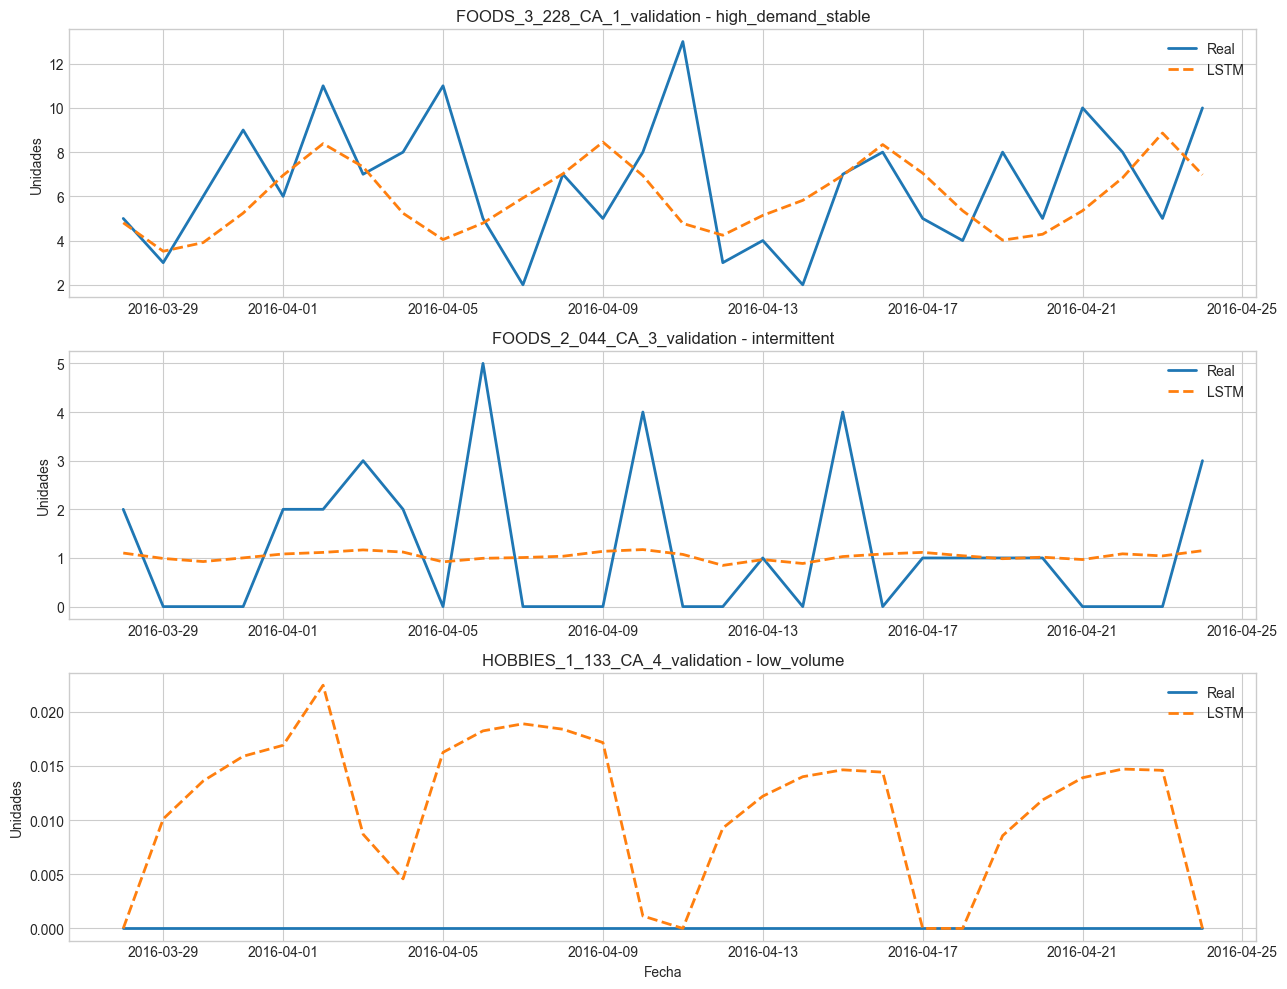

In [8]:
fig, axes = plt.subplots(len(BENCHMARK_PRODUCTS), 1, figsize=(13, 10), sharex=False)

for ax, (series_id, label) in zip(axes, BENCHMARK_PRODUCTS):
    pred_df = predictions[series_id]
    ax.plot(pred_df["date"], pred_df["actual"], label="Real", linewidth=2)
    ax.plot(pred_df["date"], pred_df["predicted"], label="LSTM", linestyle="--", linewidth=2)
    ax.set_title(f"{series_id} - {label}")
    ax.set_ylabel("Unidades")
    ax.legend()

axes[-1].set_xlabel("Fecha")
fig.tight_layout()
plt.show()

## 9. Curvas de entrenamiento

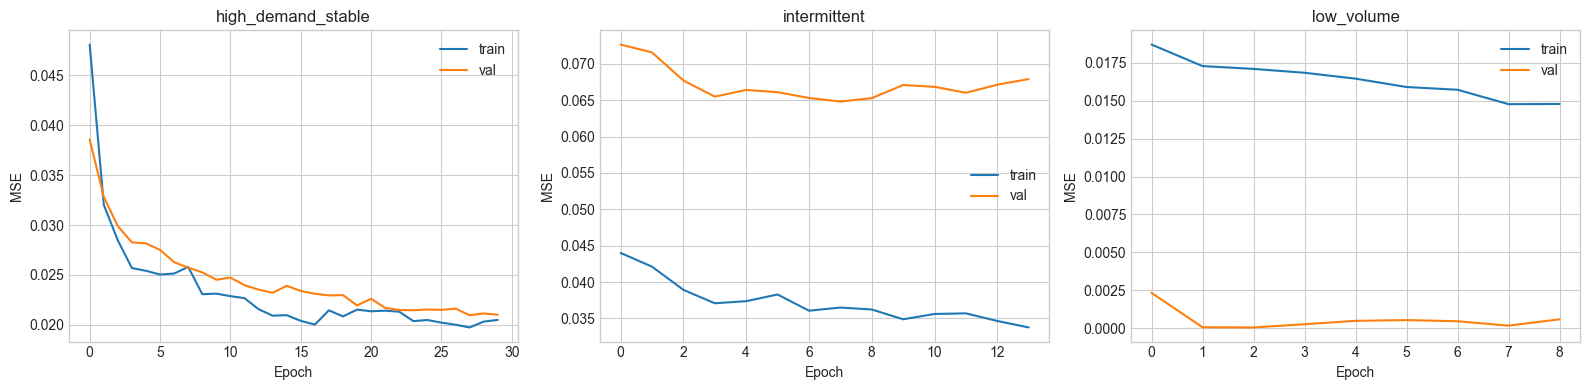

In [9]:
fig, axes = plt.subplots(1, len(BENCHMARK_PRODUCTS), figsize=(16, 4), sharey=False)

for ax, (series_id, label) in zip(axes, BENCHMARK_PRODUCTS):
    history = histories[series_id]
    ax.plot(history["loss"], label="train")
    ax.plot(history["val_loss"], label="val")
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend()

fig.tight_layout()
plt.show()

## 10. Guardar resultados opcionalmente

In [10]:
OUT_DIR = ROOT / "reports" / "keras_lstm_geeksforgeeks_three_products"
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

for series_id, pred_df in predictions.items():
    pred_df.to_csv(OUT_DIR / f"{series_id}_predictions.csv", index=False)

print(f"Metricas guardadas en: {metrics_path}")

Metricas guardadas en: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\keras_lstm_geeksforgeeks_three_products\metrics.csv
